# Portfolio Opdracht 3: 

# 1. Inleiding

Voor deze opdracht zijn we aangenomen als AI engineers bij VisionWear AI, dit is een technologisch bedrijf dat AI ontwikkeld voor de mode industrie. VisionWear AI werkt samen met webshops, modehuizen en online kleidingplatforms en ontwikkeld hiervoor AI systemen die kleding automatisch kunnen herkennen, beschrijven en nieuwe ontwerpen genereren.

Onze opdracht is om een AI systeem te bouwen dat de volgende dingen kan:

- Kledingstukken automatisch detecteren in afbeeldingen
- Productbeschrijvingen Genereren
- Nieuwe kledingafbeeldingen genereren op basis van tekstuele beschrijvingen. 

VisionWear AI heeft hiervoor een grote dataset verzameld met modefoto's, labels en beschrijvingen, en wij gaan die gebruiken voor de bovenstaande opdracht. We gaan dit doen in 3 delen.
1. Trainen van een model om de kledingstukken en accessoires te identificeren in afbeeldingen.
2. Trainen van een model dat tekstbijschriften te genereren om de kledingstukken te beschrijven.
3. Trainen van een model dat op basis van tekstbijschriften afbeeldingen kan genereren die de kledingstukken beschrijven (met modetermen).

De tekst uit deze opdracht wordt in het engels gegenereerd.

## 1.1. Setup en Data Inladen

In [6]:
import os

# Voor een stabiele config van cuda en pytorch,
# gebruik ik deze environment variables om problemen 
# met cuda libraries en log levels te voorkomen.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Dank aan deze stackoverflow post die uitlegde ik fatsoenlijk mn cuda libraries moest linken,
# BRON: https://stackoverflow.com/questions/13428910/how-to-set-the-environment-variable-ld-library-path-in-linux 
#os.environ['LD_LIBRARY_PATH'] = '/usr/lib:/opt/cuda/targets/x86_64-linux/lib'

import torch
#import nlpaug.augmenter.word as naw


# Zet cuDNN benchmarking en determinisme tijdelijk zo dat hij de mismatch negeert
#torch.backends.cudnn.benchmark = False
#torch.backends.cudnn.deterministic = True


#from transformers import (
#    pipeline, 
#    AutoTokenizer, 
 #   AutoModelForSequenceClassification, 
 #   Trainer, 
 #   TrainingArguments, 
 #   AutoConfig,
 #   DataCollatorWithPadding,
  #  AutoModelForMaskedLM)

print(f"Pytorch CUDA beschikbaar: {torch.cuda.is_available()}")

Pytorch CUDA beschikbaar: True


In [7]:
# Inladen van libraries
# iets in de volgorde zorgt ervoor dat er geen problemen zijn met cuda libraries,
# dus laat de volgorde zo staan AUB.
import yaml, shutil, cv2, random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

from io import BytesIO
from PIL import Image
from pathlib import Path

from matplotlib import patches

from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoProcessor, BlipForConditionalGeneration
from peft import PeftModel, get_peft_model, LoraConfig, TaskType
from datasets import load_dataset



In [8]:
# En stellen hier een random state variable in, hierdoor blijven onze splits, 
# maar ook de modellering die daarbij komt kijken consistent met een set seed.
def set_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # Voor volledige GPU determinisme (waarschuwing: kan training vertragen)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seeds(65)
# En setting voor max columns uit
pd.set_option('display.max_columns', None)

In [9]:
# Omdat veel modellen vaak te groot zijn voor github, slaan we de modelresultaten op in externe 
# file locations
BASE_DIR = Path.cwd()

# Mappen voor train en test
TRAIN_DIR = BASE_DIR / "Train"
TEST_DIR = BASE_DIR / "Test"

# En de maps voor de labels en images
test_images_dir = TEST_DIR / "images"

# Hier de train, ook andere formatting voor duidelijkheid
IMAGES_DIR = BASE_DIR / "Train/images"
LABELS_DIR = BASE_DIR / "Train/labels"

# Location van de externe files
BASE_PROJECT_DIR = Path("/home/beef/Downloads/models_run")

# Instellen van de clothing labels en de corresponderende labels
GENERALIST_IDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
CLOTHING_LABELS = ["sunglass", "hat", "jacket", "shirt", "pants", "shorts", "skirt", "dress", "bag", "shoe"]

In [10]:
aaaa

NameError: name 'aaaa' is not defined

In [ ]:
# Hier maken wij de dataset aan die we gaan gebruiken voor de analyse en training
# we pakken heirbij de locatie van de images en de bijpassende labels,
# die lcoaties voegen we toe aan de df.

# Daarna pakken we de label die met de corresponderende box en de afbeelding waarin die box staat
# en voegen die ook toe.
parsed_data = []

# We pakken gewoon alle files in de image folder
for img_path in IMAGES_DIR.glob("*"):
    if img_path.suffix.lower() not in [".jpg"]:
        continue

        # en alle text files met de subboxes
    label_path = LABELS_DIR / f"{img_path.stem}.txt"

    # Dan pakken we de labels uit 
    # en aangezien het 5 infotypes bevat (clothingtype, centerx, centery, width, height),
    # splitten we het in 5.
    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        
        parts = line.strip().split()
        if len(parts) == 5:
            parsed_data.append(
                {
                    "image_path": str(img_path),
                    "label_path": str(label_path),
                    "image_name": img_path.name,
                    "class_id": int(parts[0]),
                    "center_x": float(parts[1]),
                    "center_y": float(parts[2]),
                    "width": float(parts[3]),
                    "height": float(parts[4]),
                }
            )
# en dan zetten we het om naar een pandas dataframe voor bruikbaarheid.
train_df = pd.DataFrame(parsed_data)
display(train_df.head(1))

In [ ]:
# Hier beginnen we met een korte analyse van de dataset, 
# we kijken naar de dimensies van het dataframe,
print(f"Dimensies van het DataFrame: {train_df.shape}")
# Het aantal unieke images binnen de dataset,
# aangezien er meerdere boxes per afbeelding kunnen zijn.
amount_imgs = train_df["image_name"].nunique()
print("Aantal unieke afbeeldingen:", amount_imgs)
# En als laatste het aantal missende waardes per kolom
print(f"Aantal null waarden per kolom:\n{train_df.isnull().sum()}")

**Analyse**
Uiteindelijk zien we hierboven dat:
- Er geen waardes missen binnen de numerieke kolommen
- Er meer rijen in de dataset zijn dan images, dit duidt dus op het feit dat er meerdere boxes zijn per image.

Hieronder een korte samenvatting van de gehele dataset:

**Train_DF en Train Image Files:**
- train_df shape = (8298, 8)
- Aantal train image files op schijf: 2145

| Kolomnaam | Uitleg | 
| -| -|
| image_path| Bevat het pad naar de image file | 
|label_path | Bevat het pad naar het txtbestand met de afmetingen voor de image | 
| image_name| Bevat de naam van het corresponderende image file | 
| class_id| Bevat de numerieke categorie van het clothing item|
| center_x| Bevat het centrale x coordinaat van de bounding box |
| center_y| Bevat het centrale y coordinaat van de bounding box|
| width| Bevat de breedte van de bounding box|
| height| Bevat de hoogte van de bounding box|



# 2. EDA

Hieronder beginnen we met de EDA, hier gaan we vooral kijken naar de bounding boxes en hoevaak ze voorkomen per image.

In [ ]:
# Hier hebben we vaste kleuren ingesteld voor de kledingsstukken, 
# zodat alles consistent blijft qua overzicht en graphics.
clothing_colors = {
    'sunglass': "#ff0000",  
    'hat': "#ff7b00",
    'jacket': "#a29a00", 
    'shirt': "#b7ff00",  
    'pants': "#00FF6A",   
    'shorts': "#00ffe5",  
    'skirt': "#0000ff",     
    'dress': "#6f00ff",
    'bag': "#d400ff", 
    'shoe': "#ff0090"}

# En hier hebben we een mapping van class_id's naar labels, 
# zodat we makkelijk kunnen zien welke class_id bij welk kledingstuk hoort.
clothing_labels = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe",}

# Dan linken we de class_id's aan de class_names, 
# zodat we makkelijk kunnen zien welke class_id bij welk kledingstuk hoort.
train_df['class_name'] = train_df['class_id'].map(clothing_labels)

## 2.1. Aantal Kledingstukken per Foto

In [ ]:
# We beginnen met een simpele analyse van de dataset, 
# namelijk de verdeling van het aantal kledingstukken per foto.
df_summary = train_df.groupby('image_name').agg(totaal_tags=('class_id', 'count')).reset_index()

# De min en max
max_stukken = df_summary['totaal_tags'].max()
min_stukken = df_summary['totaal_tags'].min()


# En dan een simpele barchart voor de eerste visual
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_summary, 
    x='totaal_tags', 
    discrete=True, 
    color="#ff0000", 
    alpha=1)

plt.title('Verdeling van het Aantal Kledingstukken per Foto', fontsize=14, pad=15)
plt.xlabel('Aantal Kledingstukken + Accessoires op de foto', fontsize=11)
plt.ylabel('Aantal foto\'s', fontsize=11)
plt.xticks(range(int(min_stukken), int(max_stukken) + 1))
plt.grid(axis='y', linestyle='--', alpha=1)

plt.show()

**Analyse:**

We zijn begonnen naar het aantal kledingstukken die voorkomen per foto.

Hierboven zien we die dus, we zien hier niets onverwachts. De meeste foto's hebben tussen de 3 en 5 kledingstukken, en zoals later gezien wordt zijn niet alle kledingstukken gelabeld dus dit leidt verder niet tot nieuwe inzichten. 

Toch zijn er een paar foto's met een enkel kledingstuk, en waarschijnlijk zijn er geen images van mensen met een enkel kledingstuk, en zoals we later zien missen er hier en daar gewoon een paar boxes.

## 2.2. Aantal Kledingssoorten Aanwezigheid

We gaan hieronder verder met de analyse door te kijken naar de aanwezigheid van alle kledingstukken, dat gaan we hieronder nogmaals doen met een simpele barchart.

In [ ]:
# Nu gaan we kijken naar de verdeling van de specifieke kledingstukken in de dataset,
# Hierbij kijken we gewoon naar value counts en plotten deze 
aantallen_van_aantallen = train_df['class_name'].value_counts()

plot_colors = [clothing_colors.get(name, "#333333") for name in aantallen_van_aantallen.index]

plt.figure(figsize=(10, 6))

bars = plt.bar(aantallen_van_aantallen.index, aantallen_van_aantallen.values, color=plot_colors, edgecolor='black', alpha=0.85)


for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 10, 
        f'{int(yval)}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold')

plt.title('Totale Verdeling van Kledingstukken in de Dataset', fontsize=14, pad=20, weight='bold')
plt.xlabel('Kledingcategorie', fontsize=12, labelpad=10)
plt.ylabel('Totale Aantal', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()

**Analyse:**

Zoals we hierboven zien zijn de verschillende kledingstukken en accessoires niet gelijk verdeeld over de dataset. We zien dat schoenen veruit het meest voorkomen, maar dit is ook logisch aangezien er van de overige categorieen geen alternatief is voor shoes, bevalve barefoot maar dat is geen categorie.

Verder zien we ook dat van de accesoiries dat bag veruit het meest voorkomt, daarna pas sunglasses en hats. 

Maar dit geeft uiteindelijk een oneerlijk beeld van de representatie van de kledingstukken, daarom gaan we het hieronder groeperen.

### 2.2.1. Kledinstukken Gegroepeerd op Categorie

Hieronder gaan we dus nogmaals de verdelingen plotten, maar deze keer groeperen we ze op de algemene plek op het lichaam waar ze horen.

In [ ]:
# We groeperen de kledingstukken in hoofdgroepen, 
# zodat we een beter overzicht krijgen van de verdeling 
# van de verschillende soorten kledingstukken.
# Dress hebben we hier zometeen dubbel omdat het functioneert als legs als torso.
hoofdgroepen_mapping = {
    'pants': 'Legwear',
    'shorts': 'Legwear',
    'skirt': 'Legwear',
    'shirt': 'Torsokleding',
    'bag': 'Accessoires',
    'sunglass': 'Accessoires',
    'hat': 'Accessoires',
    'shoe': 'Footwear',
    'jacket': 'Outerwear'}

# Copy make voor edits
plot_df = train_df.copy()

# Dan linken we de hoofdgroepen aan de class_names
plot_df['hoofdgroep'] = plot_df['class_name'].map(hoofdgroepen_mapping).fillna('Overig')

# En dresses dubbel
dresses = plot_df[plot_df['class_name'] == 'dress'].copy()

# En dan alles toevoegen aan een df
if not dresses.empty:
    dresses_torso = dresses.copy()
    dresses_torso['hoofdgroep'] = 'Torsokleding'
    
    dresses_legwear = dresses.copy()
    dresses_legwear['hoofdgroep'] = 'Legwear'
    
    plot_df = plot_df[plot_df['class_name'] != 'dress']
    
    plot_df = pd.concat([plot_df, dresses_torso, dresses_legwear], ignore_index=True)

In [ ]:
# Dan gaan we hier de verdeling van de hoofdgroepen plotten,
grouped_data = pd.crosstab(plot_df['hoofdgroep'], plot_df['class_name'])
current_columns = grouped_data.columns

# en hier halen we de kleuren op voor de huidige class_names
plot_colors = [clothing_colors.get(name, "#333333") for name in current_columns]


fig, ax = plt.subplots(figsize=(11, 7))  
grouped_data.plot(kind='bar', stacked=True, color=plot_colors, edgecolor='black', alpha=0.85, ax=ax)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(
            x + width/2, 
            y + height/2,  
            f'{int(height)}', 
            ha='center', 
            va='center', 
            fontsize=10, 
            weight='bold',
            color='white'  
        )

# Nog een rode lijn voor het totaal aantal afbeeldingen, 
# zodat we kunnen zien hoeveel afbeeldingen er zijn in vergelijking met het aantal labels,
# per lichaamsdeel
ax.axhline(
    y=amount_imgs, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Totaal aantal afbeeldingen ({amount_imgs})' )

# En hier voegen we de totale aantallen en percentages toe boven elke bar,
# zodat we kunnen zien hoeveel labels er zijn per hoofdgroep,
for i, total in enumerate(grouped_data.sum(axis=1)):
    percentage = (total / amount_imgs) * 100
    
    ax.text(
        i, 
        total + (grouped_data.values.max() * 0.02),  
        f'Totaal: {int(total)}\n({percentage:.1f}%)', 
        ha='center', 
        va='bottom', 
        weight='bold', 
        fontsize=10)
    
plt.title('Gegroepeerde Verdeling van Kledingstukken (en % van unieke afbeeldingen)', fontsize=14, pad=25, weight='bold')
plt.ylabel('Totale Aantal Labels', fontsize=12, labelpad=10)
plt.xlabel('Hoofdgroep', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11) 

# En nog een hoger limiet voor een nette graph
ax.set_ylim(0, grouped_data.sum(axis=1).max() + 200)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Kledingstukken", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

Als we alleen zouden kijken naar de categorieen los van elkaar zien we een heel scheve verdeling, maar als we hieronder zouden kijken naar de kledingstukken gegrrpepeerd op de kledingscategorie waar ze bij behoren zien we een heel ander verhaal:

- Legwear
    - Pants
    - Shorts
    - Skirt
- Torsokleding
    - Dress
    - Shirt
- Accesseroires
    - Bag
    - Sunglasses
    - Hat
- Footwear
    - Shoes
- Outerwear
    - Jacket


We hebben hierbij ook dress bij legwear en torsokleding gezet, dresses functioneren als beide en als deze ontbrak uit een van de 2, zou dat duiden op mensen zonder broek en/of shirt.

Verder zien we dat outerwear/jacket veruit het minste is, maar ook logisch aangezien deze naast accesoires de optionele kledingstuk is, verder kan de vage definitie van jacket ook de uitleg zijn voor de dip die we zien bij torsokleding. En dat soms jacket wordt genomen als een enkel kledinstuk voor de torso.

Verder uit accessoires zien we dat bags veruit het meeste voorkomen.

Hierbij is het opvallendste de missende schoenen en om daar inzicht in te krijgen gaan we in dit volgende hoofdstuk kijken naar de image data en de boxes in de foto's.

## 2.3. Fotos

In dit deel van de EDA gaan we de images analyseren en ook de boxes binnen die images analyseren.

We beginnen hieronder met de image sizes.

In [ ]:
# Voor elke image in de Train en Test directories
# lezen we de images in met OpenCV en pakken de unieke resoluties
def check_sizes(dir_path):
    return {cv2.imread(str(f)).shape[:2] for f in dir_path.glob("*.jpg")}

# En de functie toepassen op de directories
train_sizes = check_sizes(IMAGES_DIR)
test_sizes = check_sizes(test_images_dir)
print(f"Train formaten: {train_sizes}")
print(f"Test formaten: {test_sizes}")

**Analyse:**

We zien hierboven dat alle images dezelfde afmetingen hebben (600 x 400 pixels), we hoeven dus bij later modelleren alleen de verhouding van 3 tot 2 in gedachte houden, maar niet verschillende afmetingen.

### 2.3.1. Subboxes per Image

In [ ]:
# Hieronder 3 aparte functies om de breedte, hoogte en oppervlakte 
# van de bounding boxes te plotten

# We gebruiken hiervoor cv2

def plot_absolute_width_horizontal(df, images_dir):
    plot_df = df.copy()
    
    img_dims = {f.name: cv2.imread(str(f)).shape[1] for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    plot_df['abs_width'] = plot_df['width'] * plot_df['image_name'].map(img_dims)
    # En sorteren het per gemiddelde
    order = plot_df.groupby("class_name")["abs_width"].median().sort_values(ascending=False).index

    plt.figure(figsize=(10, 8))
    sns.boxplot(
        data=plot_df, 
        x="abs_width", 
        y="class_name", 
        order=order, 
        palette=clothing_colors, 
        hue="class_name", 
        orient='h'
    )
    
    plt.title("Breedte in Pixels per Categorie", fontsize=14, weight='bold')
    plt.xlabel("Breedte in Pixels")
    plt.ylabel("Kledingcategorie")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()


def plot_absolute_height_vertical(df, images_dir):
    plot_df = df.copy()
    img_dims = {f.name: cv2.imread(str(f)).shape[0] for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    plot_df['abs_height'] = plot_df['height'] * plot_df['image_name'].map(img_dims)

    # En sorteren het per gemiddelde
    order = plot_df.groupby("class_name")["abs_height"].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x="class_name", y="abs_height", order=order, 
                palette=clothing_colors, hue="class_name", legend=False)
    plt.title("Hoogte in Pixels per Categorie", fontsize=14, weight='bold')
    plt.ylabel("Hoogte in Pixels")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

def plot_absolute_area_vertical(df, images_dir):
    plot_df = df.copy()
    img_dims = {f.name: (cv2.imread(str(f)).shape[1], cv2.imread(str(f)).shape[0]) 
                for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    
    plot_df[['img_w', 'img_h']] = plot_df['image_name'].map(img_dims).tolist()
    plot_df["abs_area"] = (plot_df["width"] * plot_df["img_w"]) * (plot_df["height"] * plot_df["img_h"])
    
    # En sorteren het per gemiddelde
    order = plot_df.groupby("class_name")["abs_area"].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x="class_name", y="abs_area", order=order, 
                palette=clothing_colors, hue="class_name", legend=False)
    plt.title("Totaal aantal Pixels per Categorie", fontsize=14, weight='bold')
    plt.ylabel("Oppervlakte in Pixels")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

In [ ]:
plot_absolute_width_horizontal(train_df, IMAGES_DIR)
plot_absolute_height_vertical(train_df, IMAGES_DIR)
plot_absolute_area_vertical(train_df, IMAGES_DIR)

**Analyse:**

- Dress
    - Qua oppervlakte in pixels is de dress het grootst, verder zien we ook bij breedte en lengte dat hij rond de top staat. Als we kijken naar de representatie binnen de dataset (550 van de 8298), kunnen we aannemen dat er genoeg pixels zijn voor het model om dresses goed te voorspellen.
- Jacket 
    - Voor jacket geld eigenlijk precies hetzelfde als voor dress, hoewel de jacket over het algemeen breder en korter is dan de dress. Verder heeft deze ook meer representatie (777 van de 8298), we kunnen dus nogmaals aannemen dat we voldoende images hebben met Jackets.
- Pants
    - Nogmaals voor pants gelden dezelfde voorwaarden als de bovenstaande 2, hij bevat een goed totaal aantal pixels in combinatie met een goede representatie (508 van de 8298), dus nogmaals de voorspelling dat we genoeg data hebben.
- Skirt
    - Skirt zit over het algemeen in het midden over meerdere categorieeen. Het bevat een goed aantal totale pixels en een goede representatie binnen de trainset (697 van de 8298), en zal waarschijnlijk geen probleem zijn.
- Shirt
    - Shirt is vrij similair to Skirt, ze hebben allebei een vergelijkbaar totaal aantal pixels, hoewel de spreiding van shirt hoger is bij breedte. Toch heeft shirt een stuk meer representatie (1486 van de 8298), maar zal waarschijnlijk niet leiden tot problemen.
- Shorts
    - In vergelijking met bag hieronder bevatten de shorts images meer totale pixels dan bag, maar de representatie is vrij laag (395 van de 8298) in vergelijking met bag, dit wordt dus een aandachtspunt en we moeten in de gaten houden hoe deze performt bij het trainen.
- Bag
    - Bags zitten een beetje in het midden, de totale pixelcount is niet al te hoog, maar bevat een goede hoeveelheid aan representatie in de trainset (1188 van de 8298) en zal daarom waarschijnlijk niet leiden tot problemen.
- Shoe
    - Shoes bevatten dezelfde problemen als hats en sunglasses hieronder, toch heeft deze een groot voordeel, zijn gigantische aanwezigheid in representatie (2081 van de 8298), hoewel ze vaak uit weinig totale pixels bestaan zal het waarschijnlijk mogelijk zijn om ze goed te kunnen voorspellen omdat er zoveel representatie is.
- Hat
    - Zoals hieronder sunglasses ook heeft heeft hat een lage totale pixelcount en ook een lage representatie ( 273 van de 8298), zoals we later ook zien bij het visualiseren van de boxes. Zit de hoed ook vaak naar achter getrokken, het zal waarschijnlijk moeilijk zijn om voor modellen te voorspellen wat een hoed is of gewoon een grote bos haar.
- Sunglasses
    - Dit is de accesoire met de minste aanstal pixels per box, daarnaast is het de op een na minst voorkomende kledingcategorie in onze dataset (343 van de 8298), waarschijnlijk zullen we hierom dus problemen gaan ervaren aangezien we weinig data hebben in representatie en totaal aantal beschikbare pixels. Toch een kleine toevoeging, in zonnenbrillen zit weinig variation, het zijn 2 donkere afgeronde vierkanten op het hoofd dus misschien valt het toch wel mee.

Zoals hierboven genoemd zullen we waarschijnlijk problemen ervaren rondom hats en sunglasses, beide voor hun lage representatie en laag totaal aantal pixels.

Verder zien we een paar hele vreemde waarde (bijv de gigantische sunglasses van 200 pixels hoog), we gaan hieronder dus verder kijken naar de subboxes.

### 2.3.2. Opschoning

**Cleanup**

Dress was clean

Hat Width =< 45

Bag moet 42 =< hoogte
Bag Max <=390 height

Jacket 112=< hoogte
Jacket 75 =< breedte

Pants 50 =< hoogte
Pants 60 =< breedte

Shirt 54 =< hoogte
Shirt 25 =< breedte

Shoes 30 =< hoogte
Shoes 38 =< 38 widt
Shoes >= 200 hoogte

Shorts 41 =< height

Skirt min 40 height
Skirt min 25 width

Sunglasses <= 100 height


In [ ]:
# Hieronder een dict van cleanup regels
# met min of max
# dan voor height width
# en dan het pixelaantal.
CLEANUP_RULES = {
    "hat": {
        "min_width": 45
    },

    "bag": {
        "min_height": 42,
        "max_height": 390
    },

    "jacket": {
        "min_height": 112,
        "min_width": 75
    },

    "pants": {
        "min_height": 50,
        "min_width": 60
    },

    "shirt": {
        "min_height": 54,
        "min_width": 25
    },

    "shoe": {
        "min_height": 30,
        "min_width": 38,
        "max_height": 200
    },

    "shorts": {
        "min_height": 41
    },

    "skirt": {
        "min_height": 40,
        "min_width": 25
    },

    "sunglass": {
        "max_height": 100
    }
}

In [ ]:
def cleanup_filter_train_df(
    df,
    images_dir,
    cleanup_rules,
    image_extension="*.jpg",
    show_details=True
):
    """
    Filtert rijen uit train_df op basis van absolute bounding-box width/height.

    Er worden geen bestanden verplaatst of aangepast.
    Alleen rijen uit de dataframe worden verwijderd.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame met kolommen:
        image_name, class_name, width, height

    images_dir : str of Path
        Map waarin de train images staan.

    cleanup_rules : dict
        Regels per class_name.

        Voorbeeld:
        {
            "jacket": {"min_height": 112, "min_width": 75},
            "shoe": {"min_height": 30, "min_width": 38, "max_height": 200}
        }

    image_extension : str
        Bestandspatroon, standaard "*.jpg".

    show_details : bool
        Of de geflagde rijen en samenvatting getoond worden.

    Returns
    -------
    cleaned_df : pd.DataFrame
        DataFrame zonder de geflagde rijen.

    removed_df : pd.DataFrame
        DataFrame met de verwijderde/geflagde rijen.

    summary_df : pd.DataFrame
        Samenvatting per label: origineel, verwijderd, overgebleven.
    """

    images_dir = Path(images_dir)
    plot_df = df.copy()

    # Originele index bewaren zodat we exact dezelfde rijen kunnen verwijderen
    plot_df["_original_index"] = plot_df.index

    # Afbeeldingsdimensies ophalen
    img_dims = {}

    for f in images_dir.glob(image_extension):
        img_tmp = cv2.imread(str(f))
        if img_tmp is not None:
            img_h, img_w = img_tmp.shape[:2]
            img_dims[f.name] = (img_w, img_h)

    plot_df["img_dims"] = plot_df["image_name"].map(img_dims)

    # Rijen zonder image dimensions niet verwijderen, maar wel behouden
    rows_without_dims = plot_df["img_dims"].isna().sum()
    if rows_without_dims > 0:
        print(f"Let op: {rows_without_dims} rijen hebben geen gevonden image-dimensies en worden niet gefilterd.")

    filter_df = plot_df.dropna(subset=["img_dims"]).copy()

    filter_df["img_w"] = filter_df["img_dims"].apply(lambda x: x[0])
    filter_df["img_h"] = filter_df["img_dims"].apply(lambda x: x[1])

    # Absolute boxgroottes in pixels
    filter_df["abs_width"] = filter_df["width"] * filter_df["img_w"]
    filter_df["abs_height"] = filter_df["height"] * filter_df["img_h"]

    flagged_parts = []

    for class_name, rules in cleanup_rules.items():
        class_df = filter_df[filter_df["class_name"] == class_name].copy()

        if len(class_df) == 0:
            continue

        class_df["cleanup_reason"] = ""

        mask = pd.Series(False, index=class_df.index)

        if "min_height" in rules:
            rule_mask = class_df["abs_height"] < rules["min_height"]
            class_df.loc[rule_mask, "cleanup_reason"] += f"abs_height < {rules['min_height']}; "
            mask = mask | rule_mask

        if "max_height" in rules:
            rule_mask = class_df["abs_height"] > rules["max_height"]
            class_df.loc[rule_mask, "cleanup_reason"] += f"abs_height > {rules['max_height']}; "
            mask = mask | rule_mask

        if "min_width" in rules:
            rule_mask = class_df["abs_width"] < rules["min_width"]
            class_df.loc[rule_mask, "cleanup_reason"] += f"abs_width < {rules['min_width']}; "
            mask = mask | rule_mask

        if "max_width" in rules:
            rule_mask = class_df["abs_width"] > rules["max_width"]
            class_df.loc[rule_mask, "cleanup_reason"] += f"abs_width > {rules['max_width']}; "
            mask = mask | rule_mask

        flagged_class_df = class_df[mask].copy()

        if len(flagged_class_df) > 0:
            flagged_parts.append(flagged_class_df)

    if len(flagged_parts) > 0:
        removed_df = pd.concat(flagged_parts, ignore_index=True)
    else:
        removed_df = pd.DataFrame(columns=list(filter_df.columns) + ["cleanup_reason"])

    # Indexen verwijderen uit originele df
    removed_indices = set(removed_df["_original_index"].tolist())

    cleaned_df = df.drop(index=removed_indices).copy()
    cleaned_df = cleaned_df.reset_index(drop=True)

    # Samenvatting maken
    original_counts = df["class_name"].value_counts().rename("original_count")
    removed_counts = removed_df["class_name"].value_counts().rename("removed_count")
    remaining_counts = cleaned_df["class_name"].value_counts().rename("remaining_count")

    summary_df = pd.concat(
        [original_counts, removed_counts, remaining_counts],
        axis=1
    ).fillna(0).astype(int)

    summary_df["removed_percentage"] = (
        summary_df["removed_count"] / summary_df["original_count"] * 100
    ).round(2)

    summary_df = summary_df.sort_index().reset_index()
    summary_df = summary_df.rename(columns={"index": "class_name"})

    
    print(f"Oorspronkelijk aantal rijen: {len(df)}")
    print(f"Aantal verwijderde rijen: {len(removed_df)}")
    print(f"Aantal overgebleven rijen: {len(cleaned_df)}")

    print("\nSamenvatting per label:")
    display(summary_df)

    if len(removed_df) > 0:
        print("\nVerwijderde/geflagde rijen:")
        display_cols = [
            "image_name",
            "class_name",
            "abs_height",
            "abs_width",
            "cleanup_reason"
        ]


        display(
            removed_df[display_cols]
            .sort_values(["class_name", "image_name"])
            .reset_index(drop=True)
        )

    return cleaned_df, removed_df, summary_df

In [ ]:
cleaned_train_df, removed_train_df, cleanup_summary_df = cleanup_filter_train_df(
    df=train_df,
    images_dir=IMAGES_DIR,
    cleanup_rules=CLEANUP_RULES,
    show_details=True
)

### 2.3.2. Subboxes Plotten 

In [ ]:
# Hieronder plotten we 4 random images,
# zodat we ze kunnen scannen voor anomalies.
def plot_fashion_grid(df):
    unique_images = df["image_name"].unique()
    chosen_images = np.random.choice(unique_images, size=4, replace=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()  
    
    for i, image_name in enumerate(chosen_images):
        ax = axes[i]
        
        img_objects = df[df["image_name"] == image_name]
        
        img_path = img_objects.iloc[0]['image_path']
        
        image = cv2.imread(img_path)
        img_h, img_w, _ = image.shape
        
        ax.imshow(image)
        
        for _, row in img_objects.iterrows():
            c_name = row["class_name"]
            box_color = clothing_colors.get(c_name, "#FFFFFF")
            
            w = row["width"] * img_w
            h = row["height"] * img_h
            xmin = (row["center_x"] - row["width"] / 2) * img_w
            ymin = (row["center_y"] - row["height"] / 2) * img_h
            
            rect = patches.Rectangle(
                (xmin, ymin),
                w,
                h,
                linewidth=2.0,
                edgecolor=box_color,
                facecolor="none",
            )
            ax.add_patch(rect)
            
            text_color = "black" 
            
            ax.text(
                xmin,
                ymin - 8 if ymin - 8 > 0 else ymin + 15,  
                f" {c_name.upper()} ",
                color=text_color,
                fontsize=8,
                weight="bold",
                bbox=dict(facecolor=box_color, edgecolor=box_color, alpha=0.85, pad=1),
            )
        
        ax.set_title(f"{image_name}", fontsize=11, pad=5)
        ax.axis("off")
        
    plt.suptitle("EDA Visualisatie: 2x2 Kleding Grid", fontsize=18, weight="bold", y=0.95)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_fashion_grid(cleaned_train_df)

### 2.3.3. Boxes Anomalies

Zoals hierboven dus te zien is bevatten de meeste fotos meerdere delen van de afbeeldingen die een kledingsstuk bevatten.

1. Anomalies en Fouten

<img src="nosunglass 2.png" width="400">
<img src="nosunglass.png" width="400">
<br>
<img src="nojacket.png" width="400">
<img src="nobag.png" width="400">
<br>

Toch zagen we bij kort browsen door de images een paar anomalies zoals hieronder te zien zijn, zoals sunglasses met 1 glas en een paar mislabeled stukken clothing.


2. Shoeless:


<img src="susanshoeless1.png" width="400">
<img src="susanshoeless2.png" width="400">
<br>

Verder zagen we dat er verassend weinig shoes waren voor wat de verwachting was. Zoals hieronder te zien waren er een paar images waar schoenen in zaten, maar geen box er om heen. Dit is uiteindelijk geen probleem want we hebben meer dan genoeg data, maar wel een observatie.


3. Twee Personen

<img src="2_ppl.png" width="400">
<br>
Uiteindelijk hebben we ook 1 foto gevonden met 2 personen, zoals hierboven te zien is. Dit in de enige die we hebben gevonden en dus verwijderen deze foto en labels voor zekerheid.

4. Verkeerde Afmetingen

<img src="big_glasses.png" width="400">\
<img src="big_glasses_2.png" width="400">
<br>

Zoals verder terug al genoemd was, waren er een paar images met heel erg vreemde afmeting, zoals deze "sunglasses" hierboven.

5. Andere Anomalies

Ook zagen we hier een daar wat watermarks, ook door de boxes van de kledingsstukken heen, gelukkig was dit bij de random images die wij bekeken hadden heel zeldzaam, maar het is een aandachtspunt.

Het is voor ons niet mogelijk om deze te cleanen want het zijn 2145 images. Dus moeten we het model iets aan de algemenere kant houden zodat hij niet overgetraind wordt op foutieve images.



In [ ]:
aaaaa

# Opdracht 2: Objectdetectie
 In deze deelopdracht werk je uitsluitend met de images en labels uit de data voor
deel 1. Bouw en train een objectdetectie model om de tien klassen kleding en
modeaccessoires in de dataset te detecteren en hun locaties te voorspellen met
behulp van bounding-boxes.

 Beschrijf in je eigen woorden hoe je model voorspellingen doet.

 Beschrijf hoe je de afbeeldingen voorbewerkt.

 Beschrijf in detail welke stappen, indien aanwezig, je onderneemt voor feature
engineering.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepochs.

 Beschrijf de lossfunctie voor dit model in je eigen woorden en hoe deze werk

In [ ]:
display(cleaned_train_df)

# 3 Modelleren



In [ ]:
import os
from pathlib import Path
import shutil
import cv2

def create_dataset_from_paths(image_paths, label_paths, dataset_root):
    (dataset_root / "train/images").mkdir(parents=True, exist_ok=True)
    (dataset_root / "train/labels").mkdir(parents=True, exist_ok=True)
    
    for img_path, label_path in zip(image_paths, label_paths):
        # Controleer of het pad bestaat
        if not os.path.exists(img_path):
            print(f"Warning: Afbeelding {img_path} bestaat niet. Overgeslagen.")
            continue
        
        # Kopieer de originele afbeelding en label
        shutil.copy(img_path, dataset_root / "train/images" / Path(img_path).name)
        
        shutil.copy(label_path, dataset_root / "train/labels" / Path(label_path).name)
        
        # Maak een gespiegeld versie van de afbeelding
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Warning: Kan afbeelding {img_path} niet lezen. Overgeslagen.")
            continue
        
        flipped_img_path = dataset_root / "train/images" / f"flip_{Path(img_path).name}"
        cv2.imwrite(str(flipped_img_path), cv2.flip(img, 1))
        
        # Kopieer de gespiegled label
        shutil.copy(label_path, dataset_root / "train/labels" / f"flip_{Path(label_path).name}")
        
        with open(dataset_root / "train/labels" / f"flip_{Path(label_path).name}", 'r') as f:
            lines = [l.split() for l in f.readlines()]
        
        # Verwerk de gespiegled label
        with open(dataset_root / "train/labels" / f"flip_{Path(label_path).name}", 'w') as f:
            for line in lines:
                new_cls = int(line[0])
                xc, yc, w, h = map(float, line[1:])
                f.write(f"{new_cls} {1.0 - xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

# Voorbeeld aanroep van de functie
image_paths = cleaned_train_df['image_path']
label_paths = cleaned_train_df['label_path']


dataset_root = BASE_PROJECT_DIR / "ultimate_generalist_dataset"
if dataset_root.exists():
    shutil.rmtree(dataset_root)
    
create_dataset_from_paths(image_paths, label_paths, dataset_root)

In [ ]:
yaml_path = BASE_PROJECT_DIR / "ultimate_generalist.yaml"
with open(yaml_path, "w") as f:
    yaml.dump({
        "path": str(dataset_root),
        "train": "train/images",
        "val": "train/images", 
        "nc": len(CLOTHING_LABELS), 
        "names": CLOTHING_LABELS
    }, f)

# YOLO-model trainen
model = YOLO("yolo26n.pt")
model.train(data=str(yaml_path), 
             epochs=150, 
             dropout=0.3,
             imgsz=576, 
             project=str(BASE_PROJECT_DIR), 
             name="ultimate_gen_mirror")

# 4. H&M

In dit hoofdstuk gaan wij een model maken op basis van de H&M dataset, deze bevat images van kledingstukken en corresponderende beschrijvingen van die kledingstukken. Wij gaan hiermee eerst een model bouwen wat tekstuele beschrijvingen kan genereren van images van kleding (dit hoofdstuk), en in het hoofdstuk dat daarop volgt, een model wat images kan genereren van tekstuele beschrijvingen van kleding.

BRON: https://huggingface.co/datasets/tomytjandra/h-and-m-fashion-caption-12k/viewer
- We hebben niet kunnen vinden waar deze dataset specifiek vandaan komt, maar we kunnen speculeren met redelijke zekerheid dat hij afkomstig is van de winkelketen H&M.

We beginnen hieronder met een korte eda op de H&M Database

## 4.1. H&M EDA


In [11]:
# Het load dataset halen we de dataset van huggingface
hm_df_not_panda = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")
hm_df = hm_df_not_panda['train'].to_pandas() 

In [12]:
print(hm_df.columns)
print(hm_df.shape)
display(hm_df.head(1))

Index(['text', 'image'], dtype='str')
(12437, 2)


,text,image
0,solid dark blue fitted top in soft stretch jer...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...


**Analyse**
</br>
<img src="parquet.png" width="400">
</br>
Zoals we hierboven zien zijn observeren we de volgende dingen:

- Afmetingen zijn 12437 rijen, met een image file en txt file die het kledinstuk beschrijft.
- De files direct van huggingface staan in het .parquet format, deze wordt gebruikt om grote dataset efficient op te slaan.
- De images staan nog in het byte format, en moeten dus nog omgezet worden naar een bruikbare image format.

## 4.2. Images

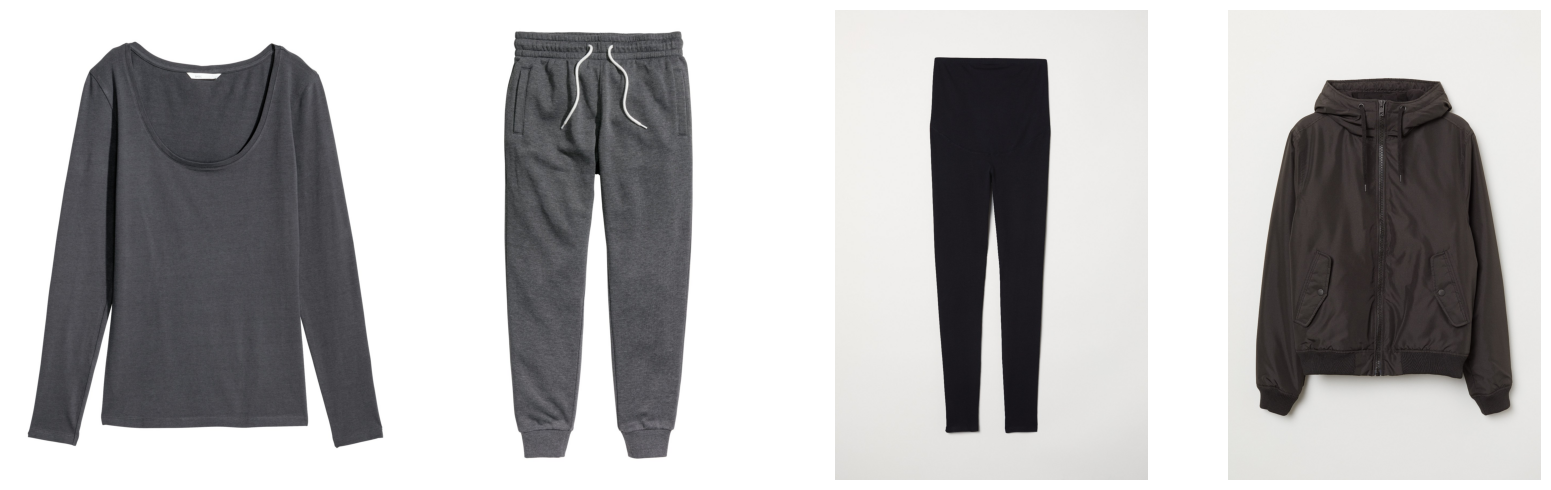

Max Breedte: 2809
Max Hoogte: 1750


In [13]:
# Hier plotten we een paar images voor overzicht,
# en daaronder de max afmetingen
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, ax in enumerate(axes):
    img_data = hm_df.loc[i, "image"]
    # We gebruiken bytesIO om de bytes uit de dataset
    # om te zetten naar daadwerkelijke images
    image = Image.open(BytesIO(img_data["bytes"])).convert("RGB")
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

sample_size = 12437
images = hm_df_not_panda['train'].select(range(sample_size))["image"]

# Hier berekenen we de afmetingen van de images,
# zodat we de max kunnen vinden voor height en width
sizes = [img.size for img in images]
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Max Breedte: {np.max(widths)}")
print(f"Max Hoogte: {np.max(heights)}")

**Analyse**

Als we gaan kijken naar de images, zien we:

- Dat elke kleding image omringt is door white of lightgray space
- Dat de max width 2809 Pixels is
- Dat de max height 1750 Pixels is


## 4.3. Text

In dit deel gaan we kort kijken naar de txt files uit de H&M dataset. WE kijken hierbij kort naar de contents, het aantal woorden, .....

1: all over pattern dark blue short-sleeved dress in soft jersey with a seam and drawstring at the waist
2: all over pattern dark blue short straight-cut dress in a viscose weave with a round neckline that has a small opening and a concealed button at the back of the neck long sleeves with slits and ties at the cuffs unlined
3: solid black jersey tunic with a v-neck short sleeves and detachable tie belt at the waist unlined
4: solid black long-sleeved body in jersey with a v-shaped mesh section at the front a seam at the hips and a microfibre lower section concealed press-studs at the crotch
5: solid light beige short sleeveless dress in pleated jersey with a slight sheen round neckline with an opening and button at the back of the neck a seam at the waist with a detachable tie belt and a flared skirt unlined
6: all over pattern beige knee-length dress in ribbed jersey with a ballerina neckline front and back 34-length sleeves seam at the waist and flared skirt unlined
7: solid light p

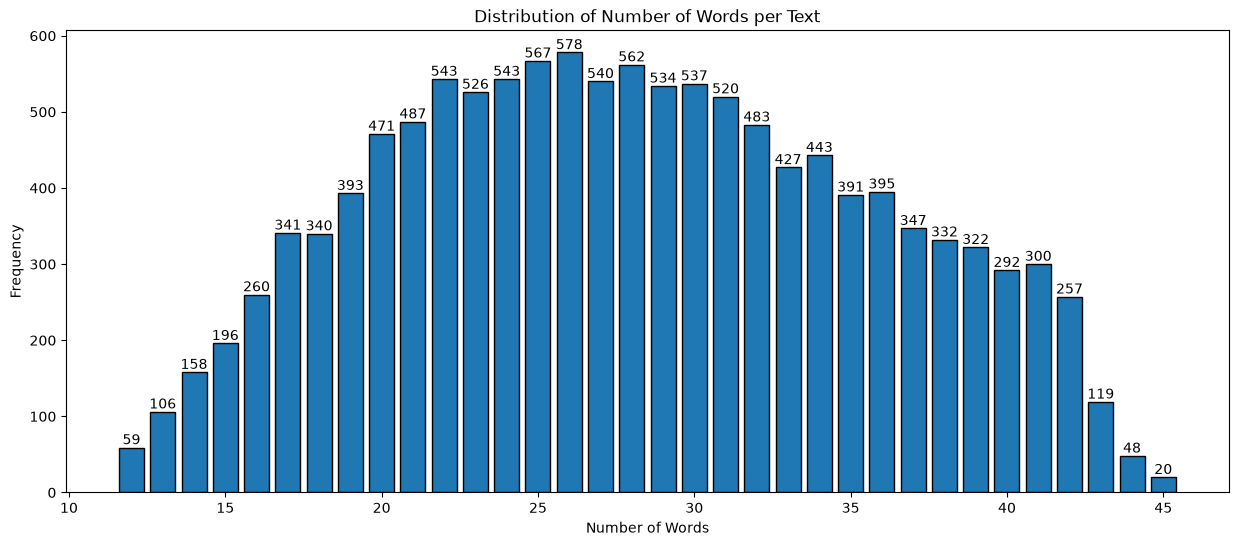

In [14]:
# Hieronder bekijken 10 random stukken tekst uit de H&M Dataset,
# voor een kort overzicht.
random_samples = hm_df_not_panda['train'].shuffle().select(range(10))
for i, item in enumerate(random_samples):
    print(f"{i+1}: {item['text']}")

# Hier pakken we wel de pandas dataframe voor bruikbaarheid
# voor visuals
texts = hm_df['text']
# En splitsen deze voor de word counts
word_counts = [len(text.split()) for text in texts]

word_count_freq = {}
for count in word_counts:
    if count in word_count_freq:
        word_count_freq[count] += 1
    else:
        word_count_freq[count] = 1

# En maken hier lists van voor de aantallen per aantal woorden per txt file,
aantallen = list(word_count_freq.keys())
aantallen_van_aantallen = list(word_count_freq.values())

plt.figure(figsize=(15, 6))
plt.bar(aantallen, aantallen_van_aantallen, edgecolor='black')
plt.title('Distribution of Number of Words per Text')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

for i, count in enumerate(aantallen):
    plt.text(count, aantallen_van_aantallen[i], 
             str(aantallen_van_aantallen[i]), 
             ha='center', 
             va='bottom')

plt.show()

**Analyse**
We zien hierboven dus:
- Dat de spreiding van het aantal woorden vooral ligt tussen 12 en 45
- Daarnaast ligt de top tussen 20 en 40, met een kleine spreiding aan de buitenkanten
- Dit komt waarschijnlijk ook door het feit dat meer simpelere kleding minder details heeft, en we kunnen dus speculeren dat we dit ook mee moeten nemen voor het modelleer gedeelte.

## 4.4. Image Size Aanpassing

Om de input consistent te houden gaan we alle images reshapen naar dezelde afmetingen, we hebben hier geluk omdat alle images omringt zijn met een wit/lichtgrijze achtergrond. We kunnen dus gewoon whitespace toevoegen waar nodig.

In [15]:
# Hier stellen we de gewenste image size in voor de H&M images
target_size = (2809, 1750)

# Nogmaals omdat 17 k images technisch gezien niet te veel is voor github, 
# om het uberhaupt te oploaden en dan retrieven duurt lang vooral na data augmentation
# dus houden we dit ook local.
new_dir_path = BASE_PROJECT_DIR / "resized_images_and_texts"
new_dir_path.mkdir(parents=True, exist_ok=True)

# En dan lopen we de dataset door
# En zetten al die bytes om naar bruikbare images
for i, row in hm_df.iterrows():
    image = Image.open(BytesIO(row["image"]["bytes"])).convert("RGB")
    text = row["text"]

    # Dan pakken we de heights en widths
    old_width, old_height = image.size

    # en dan bepalen we de gewenste padding
    # door de huidige afmetingen af te trekken van de gewenste image size
    # en dan delen door 2 aangezien er boven en onder
    # en links en rechts van de image wat toegevoegd moet worden.
    width_padding = (target_size[0] - old_width) // 2
    height_padding = (target_size[1] - old_height) // 2

    # en dan met die nieuwe image size, voegen we white toe voor hoeveel mogelijk moet
    new_image = Image.new("RGB", target_size, color="white")
    new_image.paste(image, (width_padding, height_padding))
    base_name = f"resized_image_{i:05d}"

    # en dan in de nieuwe folder zetten
    image_path = new_dir_path / f"{base_name}.jpg"
    text_path = new_dir_path / f"{base_name}.txt"

    # we gebruiken quality compression van 95,
    # qua quality verliezen we praktisch niet,
    # en efficienter voor storage size
    new_image.save(image_path, quality=95)

    with open(text_path, "w", encoding="utf-8") as f:
        f.write(text)

## 4.5. Batches Maken

In [16]:
# Later gaan we een LoRa Trainen, maar dit kan niet met de volledige dataset in 1 keer
# daarom maken we hier batches voor de resized image files met de corresponderende txt files.

# Nieuwe Externe map aanmaken
new_batch_path = BASE_PROJECT_DIR / "hm_batches"
new_batch_path.mkdir(parents=True, exist_ok=True)

# We nemen 500 images per batch, dit was na wat testen een optimaal aantal 
# voor het trainen van de LoRa later
PAIRS_PER_BATCH = 500
IMAGE_EXTENSIONS = [".jpg"]

pairs = []

# omdat de names van de images hetzelfde zijn als de txt files,
# pakken we gewoon de txt file names met .stem
# wat het file systeem achter de naam weghaald,
# en dan plakken we gewoon .jpg erachter voor de namen van de images.
for txt_path in sorted(new_dir_path.glob("*.txt")):
    stem = txt_path.stem

    image_path = None
    for ext in IMAGE_EXTENSIONS:
        candidate = new_dir_path / f"{stem}{ext}"
        # En dan een check of hij al bestaat om overbodig werk
        # of duplicates te voorkomen
        if candidate.exists():
            image_path = candidate
            break

    if image_path is not None:
        pairs.append((image_path, txt_path))
    else:
        print(f"Img niet gevonden:{txt_path.name}")


# Dan voor de gemaakte pairs
# splitsen we ze in batches van 500 (eig 1000, maar het is 500imgs + 500 txt files)
# en splijten we ze binnen die map in subfolders voor de batches
for i, (image_path, txt_path) in enumerate(pairs):
    batch_index = i // PAIRS_PER_BATCH
    batch_folder = new_batch_path / f"batch_{batch_index:03d}"
    batch_folder.mkdir(parents=True, exist_ok=True)

    shutil.copy2(image_path, batch_folder / image_path.name)
    shutil.copy2(txt_path, batch_folder / txt_path.name)

num_batches = (len(pairs) + PAIRS_PER_BATCH - 1) // PAIRS_PER_BATCH

print(f"Aantal Batches: {num_batches}")


Aantal Batches: 25


# Opdracht 3: Ondertiteling van afbeeldingen

 In deze deelopdracht werk je met de H&M images en captions dataset.

 Fine-tune een model om Engelse tekstbijschriften te genereren op basis van
afbeeldingen van kleding.

 Beschrijf in je eigen woorden hoe het model voorspellingen doet, welke lossfunctie
het gebruikt en hoe het wordt getraind.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepochs

# 5. Img2Txt Model op H&M Dataset

In [17]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

dataset = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")["train"]

dataset_split = dataset.train_test_split(
    test_size=0.1,
    seed=42
)

train_dataset = dataset_split["train"]
val_dataset = dataset_split["test"]

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['text', 'image'],
    num_rows: 11193
})
Dataset({
    features: ['text', 'image'],
    num_rows: 1244
})


In [35]:
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

base_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base",
    use_safetensors=True
)

peft_config = LoraConfig(
    r=32,
    lora_alpha=64,
    lora_dropout=0.1,
    target_modules=["query", "key", "value", "output.dense"],
    bias="none"
)

model = get_peft_model(base_model, peft_config)
model.to(DEVICE)

model.print_trainable_parameters()

Loading weights: 100%|██████████| 472/472 [00:00<00:00, 16223.02it/s]


trainable params: 6,193,152 || all params: 230,164,796 || trainable%: 2.6907


In [36]:
def collate_fn(batch):
    images = [item["image"].convert("RGB") for item in batch]
    texts = [item["text"] for item in batch]

    inputs = processor(
        images=images,
        text=texts,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

    labels = inputs["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    inputs["labels"] = labels

    return inputs

In [37]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [38]:
import torch.optim as optim
import tqdm



In [40]:
import torch
import tqdm
import torch.optim as optim

torch.cuda.empty_cache()

model.train()

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-5
)

EPOCHS = 3

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for batch in tqdm.tqdm(train_loader, desc=f"Training epoch {epoch + 1}"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()

        # Belangrijk: base_model aanroepen, niet de PEFT wrapper direct
        outputs = model.base_model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        loss = outputs.loss

  

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm.tqdm(val_loader, desc=f"Validation epoch {epoch + 1}"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            outputs = model.base_model(
                pixel_values=batch["pixel_values"],
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )

            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}")
    print(f"Train loss: {avg_train_loss:.4f}")
    print(f"Validation loss: {avg_val_loss:.4f}")

Validation epoch 1: 100%|██████████| 78/78 [00:31<00:00,  2.46it/s]


Epoch 1
Train loss: 1.9045
Validation loss: 1.4849


Validation epoch 2: 100%|██████████| 78/78 [00:30<00:00,  2.54it/s]


Epoch 2
Train loss: 1.4009
Validation loss: 1.3706


Validation epoch 3: 100%|██████████| 78/78 [00:30<00:00,  2.56it/s]

Epoch 3
Train loss: 1.2531
Validation loss: 1.2094


In [41]:
SAVE_DIR = "/home/beef/Downloads/karaoke-k-klassificatie-2026/Deep-Learning-3/blip-hm-lora"

model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

print("Model opgeslagen in:", SAVE_DIR)

Model opgeslagen in: /home/beef/Downloads/karaoke-k-klassificatie-2026/Deep-Learning-3/blip-hm-lora


In [42]:


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_MODEL_NAME = "Salesforce/blip-image-captioning-base"
LORA_DIR = "/home/beef/Downloads/karaoke-k-klassificatie-2026/Deep-Learning-3/blip-hm-lora"

processor = AutoProcessor.from_pretrained(BASE_MODEL_NAME)

base_model = BlipForConditionalGeneration.from_pretrained(
    BASE_MODEL_NAME,
    use_safetensors=True
)

model = PeftModel.from_pretrained(
    base_model,
    LORA_DIR
)

model = model.to(DEVICE)
model.eval()

print("Model geladen.")

Loading weights: 100%|██████████| 472/472 [00:00<00:00, 15019.66it/s]


Model geladen.


In [43]:
def generate_clothing_description(image_path, max_new_tokens=40):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=5,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    caption = processor.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    return caption

In [45]:
image_path = "/home/beef/Downloads/a.png"

description = generate_clothing_description(image_path)

print(description)

solid dark red satin v - neck floor - length dress with a slit at the back of the neck and a concealed zip in the side lined


# 6. Txt2Img Model

In dit deel van de opdracht draaien we het om en finetunen een voorgetrained model om met onze txt files een image te genereren van een kledingstuk.

## 6.1. Gebruikte Tools

1. SwarmUI/ComfyUI

    - Deze training is uitgevoerd met SwarmUI met ComfyUI als backend. Dit hebben we gedaan omdat SwarmUI als omgeving veel efficienter omgaat met RAM en VRAM en de offload naar CPU en RAM geheugen lijkt consistenter te werken. Terwijl de normale pytorch trainingsloop veel minder efficient omgaat met RAM, CPU en VRAM en om een meer optimale staat te bereiken is een hoop tweaking nodig.

2. Linux, Zram, Zswap, Swap Partition
    - ZRAM is een gecomprimeerde swapruimte in je RAM, de data blijft dus op je RAM maar wordt kleiner gemaakt door compressie, hierdoor past er uiteindelijk meer data in je RAM.
    - ZSWAP werkt als een soort tussenlaag tussen de swap partition en de compression, hij probeert dus eerst de data compacter te bewaren op je RAM, als dat niet mogelijk is gaat het naar de Swap Partition.
    - Swap Partition functioneert als een soort RAM backup voor linux, het is een partion op je storage drive die functioneert als nood RAM, dit voorkomt dat applications crashen bij RAM tekort. Toch is het een stuk langzamer als echte RAM, maar kan een grote stroom aan data binnen je RAM opvangen.

    - Bij het trainen van modellen is VRAM vaak de hard limit, met behulp van de RAM optimalisaties laat dit ons grotere workflows draaien, hoewel het VRAM niet vergroot. Maar het laat ons bij het trainen bepaalde tensors, activations, modelonderdelen etc. dit laat het efficienter omgaan met VRAM en hebben we een grotere buffer, want als we tegen het VRAM limiet aan lopen tijdens trainen kapt hij er meteen mee.


2. SDXL Components

    1. Unet/Diffusion Model (sd_xl_base_1.0.safetensors):
        - Dit is binnen de workflow het txt2img diffusion model, deze bepaald tijdens het trainproces stap voor stap welke ruis wordt verwijderd uit de gegeven afbeelding. 
        - Het SDXL diffusion model is afkomstig van Stability AI, een bedrijf wat zich specialiseert in het leveren van "professionele" AI Modellen. We heben niet kunnen vinden op wat voor data SDXL getraind is, maar we kunnen speculeren dat dit een grote dataset was met een grote variatie aan verschillende afbeeldingen aangezien dit model een hoop verschillende dingen kan genereren. Dit gebrek aan informatie komt waarschijnlijk vanuit het feit dat hun concurrentie die dataset dan niet kan gebruiken.
    2. Text Encoders (clip_l.safetensors en clip_g.safetensors):
        - Dit zijn de encoders de gegeven tekst omzetten naar bruikbare informatie voor het Diffusion model. En deze 2 zijn specifiek voor dit SDXL model en zullen niet werken op andere Diffusion Modellen tenzij ze dezelfde architectuur gebruiken.
    3. VAE (SDXL/sdxl_vae.safetensors):
        - Hoe clip_l en clip_g de encoders zijn voor tekst voor het model, functioneert een VAE (Variational Autoencoder) als een soort encoder en decoder voor de images voor het model. Eerst zet hij een normale image om naar een compacte latente representatie voor het model, die latente ruimte is een soort van numerieke representatie van wat de afbeelding eigenlijk is, het behoud belangrijke dingen zoals kleur, vorm en compositie. Na het trainen zet de VAE de gegenereerde afbeelding (nog steeds in die latent space), ook weer terug om naar een "bruikbare of echte" image.

3. Gebruikte Data:
    - Door al eerder te zorgen dat al de H&M images dezelfde verhoudingen hebben door padding toe te voegen, kunnen we bij het trainen van de LoRa ook diezelfde verhoudingen behouden, maar de schaal veranderen zonder dat we last krijgen van stretching. Daarnaast hadden we het voordeel dat de images uit de dataset al een witte achtergrond hadden, dit maakt het voor het model makkelijk om onderscheid te maken tussen de achtergrond en het "object" van de foto.    
    - Hierbij hebben we die batches van 500 gebruikt omdat 12k images te gelijk trainen te veel was.

4. LoRa Training
    - LoRa staat voor Low-Rank Adaptation, het is eigenlijk een manier om een groot voorgetraind model te fine tunen zonder alle originele parameters te hoeven trainen. Hierdoor blijft het grootste deel van het model bevroren en worden alleen kleine lagen toegevoegd aan het model. 
    - Daarna bij het gebruiken van het model in combinatie met die LoRa worden de getrainde gewichten aangepast op basis van de LoRa training.
    - In deze opdracht is LoRa gebruikt om het voorgetrainde SDXL model verder af te stemmen op basis van de engelse clothing descriptions. Met LoRa training is het model aangepast op de stijl en inhoud van de H&M dataset. Denk hierbij aan kledingstukken en de witte achtergrond.
    1. Loss
        - Voor de Loss hebben we MSE loss gebruikt (Mean Squared Error, berekent de gemiddelde squared fout). Bij een diffusion model vergelijkt de MSE loss de voorspelde ruis met de echte ruis, met MSE worden grote fouten strenger bestraft dan kleine fouten. Dit past uiteindelijk goed bij het denoising proces, omdat het model stap voor stap leert welke noise verwijderd moet worden.
    2. Optimizer  
        - Voor de optimizer is Adam gebruikt, dit is een veelgebruikte optimizer voor Neural Networks omdat het per parameter adaptive de weights aanpast. Dit betekent dat die verschillende weights apart worden behandeld en blijft het model stabieler tijdens het leren.
    3. Lora Rank
        - De lora rank is ingesteld op 4, deze rank bepaald hoeveel parameters worden toegevoeged, bij hogere waardes krijgt de LoRa training meer capacity om complexere patroinen te leren, maar gaat dan meer VRAM gebruiken en verhoogt ook het risico op overfitting. Uiteindelijk met wat experimentatie hebben we gekozen voor rank 4 voor een balans tussen performance, stabiliteit en VRAM Capacity.
    4. Training -en Lora Dtype
        - Voor de gebruikte datatypes hebben we gekozen voor bf16 en gebruikt dus bfloat16 precisie in plaats van volledige 32-bit floating point precisie. Dit betekent dat de tensors minder memory gebruiken, uiteindelijk blijft het model toch redelijk stabiel omdat we een LoRa trainen op een groot en al stabiel model. Daarnaast gaan we hier voor een algemeen model zonder hoge precisie.
    5. Batch Size en Steps
        - We hebben niet gebruikt gemaakt van Epochs, we hebben gekozen voor een batch size van 2 met 500 steps, aangezien we 500 images hebben per batch folder, ziet hij per training loop elke image 2 keer. Wij denken dat dit voor 12k images genoeg is voor de LoRa om van te leren.


https://stability.ai/

https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0



# Opdracht 4: Beeldgeneratie


 Geef de naam op van de modelarchitectuur die je hebt gekozen en de dataset
waarop deze vooraf is getraind.

 Je model moet een Engels tekstbijschrift als input gebruiken en een afbeelding als
output maken.

 Beschrijf in detail de stappen die worden genomen bij het finetunen van dit vooraf
getraind model.

 Beschrijf de componenten van dit model.

 Beschrijf in je eigen woorden hoe het model afbeeldingen maakt en welke lossfunctie
het gebruikt.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepoch

# Opdracht 5: Implementatie

 Maak een eenvoudige app die een foto als input gebruikt, kledingstukken en
modeaccessoires detecteert en hun locatie geeft, en tekstbeschrijvingen genereert
van elk kledingstuk in de afbeelding. Gebruik de modellen die je in de voorgaande
opdrachten hebt getraind/gefinetuned.

 De app gebruikt een foto als input en voorspelt de locatie van elk afzonderlijk
kledingstuk en modeaccessoire. Vervolgens worden de individuele
kledingstukken/mode-items voorzien van bijschriften. De bijschriften moeten voor
elk afzonderlijk gedetecteerd item afzonderlijk worden gegenereerd.

 Let op: Je hoeft deze app niet te deployen. Je hoeft alleen maar de modellen in jouw
notebook uit te voeren en de voorspellingen op de juiste manier te combineren.

 Geef een samenvatting van de uitkomsten van het modelleren.
o Geef een beknopt overzicht van de resultaten.

o (Voor deel 1) Toon je scores op Kaggle en laat zien wat de resultaten waren
van je verbeteringen op je score op Kaggle.

o (Voor deel 2 & 3) Geef voorbeelden van je getrainde modellen in actie en
evalueer hun prestaties.

o Geef een voorbeeld/voorbeelden van hoe je app kleding en modeaccessoires
detecteert en geschikte bijschriften genereert voor elk gedetecteerd ite

In [ ]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

from ultralytics import YOLO

from transformers import BlipProcessor, BlipForConditionalGeneration
from peft import PeftModel

In [ ]:
DETECTOR_PATH = "/home/beef/Downloads/models_run/ultimate_gen_mirror/weights/best.pt"

BLIP_LORA_DIR = "/home/beef/Downloads/karaoke-k-klassificatie-2026/Deep-Learning-3/blip-hm-lora/"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("Detector bestaat:", Path(DETECTOR_PATH).exists())
print("BLIP LoRA map bestaat:", Path(BLIP_LORA_DIR).exists())

In [ ]:
detector = YOLO(DETECTOR_PATH)

print("Detector geladen.")
print("Classes:")
print(detector.names)

In [ ]:
adapter_config_path = Path(BLIP_LORA_DIR) / "adapter_config.json"

with open(adapter_config_path, "r") as f:
    adapter_config = json.load(f)

print(adapter_config)

In [ ]:
base_model_name = adapter_config.get("base_model_name_or_path", None)

if base_model_name is None or base_model_name == "":
    base_model_name = "Salesforce/blip-image-captioning-base"

print("BLIP base model:", base_model_name)

processor = BlipProcessor.from_pretrained(base_model_name)

base_caption_model = BlipForConditionalGeneration.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
)

caption_model = PeftModel.from_pretrained(
    base_caption_model,
    BLIP_LORA_DIR
)

caption_model = caption_model.to(DEVICE)
caption_model.eval()

print("BLIP + LoRA geladen.")

In [ ]:
def crop_with_padding(image, box, padding=10):
    """
    Cropt een bounding box uit een PIL image met extra padding.
    box = [x1, y1, x2, y2]
    """
    width, height = image.size
    x1, y1, x2, y2 = box

    x1 = max(0, int(x1) - padding)
    y1 = max(0, int(y1) - padding)
    x2 = min(width, int(x2) + padding)
    y2 = min(height, int(y2) + padding)

    return image.crop((x1, y1, x2, y2))


def generate_caption_for_crop(crop, max_new_tokens=40):
    """
    Genereert een caption voor één kleding-crop met BLIP + LoRA.
    """
    crop = crop.convert("RGB")

    inputs = processor(
        images=crop,
        return_tensors="pt"
    ).to(DEVICE)

    if DEVICE == "cuda":
        inputs = {k: v.to(torch.float16) if v.dtype == torch.float32 else v for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = caption_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=5
        )

    caption = processor.decode(output_ids[0], skip_special_tokens=True)
    return caption


def detect_items(image, conf_threshold=0.25, imgsz=640):
    """
    Detecteert kledingstukken/accessoires in een PIL image.
    Geeft een lijst met detecties terug.
    """
    results = detector.predict(
        source=image,
        conf=conf_threshold,
        imgsz=imgsz,
        verbose=False
    )

    result = results[0]
    detections = []

    if result.boxes is None:
        return detections

    for i, box in enumerate(result.boxes):
        xyxy = box.xyxy[0].detach().cpu().numpy().tolist()
        conf = float(box.conf[0].detach().cpu().item())
        cls_id = int(box.cls[0].detach().cpu().item())
        cls_name = detector.names.get(cls_id, str(cls_id))

        detections.append({
            "item_id": i + 1,
            "class_id": cls_id,
            "class_name": cls_name,
            "confidence": conf,
            "box": xyxy
        })

    return detections


def draw_detections(image, results_table):
    """
    Tekent bounding boxes en itemnummers op de afbeelding.
    """
    output = image.copy().convert("RGB")
    draw = ImageDraw.Draw(output)

    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 18)
    except:
        font = None

    for row in results_table:
        x1, y1, x2, y2 = row["box"]

        label = f'{row["item_id"]}: {row["class_name"]}'

        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline="red",
            width=4
        )

        text_x = x1
        text_y = max(0, y1 - 24)

        draw.rectangle(
            [(text_x, text_y), (text_x + 220, text_y + 24)],
            fill="red"
        )

        draw.text(
            (text_x + 4, text_y + 2),
            label,
            fill="white",
            font=font
        )

    return output


def clothing_caption_app(image_path, conf_threshold=0.25, imgsz=640, crop_padding=15):
    """
    Complete app-pipeline:
    input foto → detecties → crops → captions → output image + dataframe.
    """
    image = Image.open(image_path).convert("RGB")

    detections = detect_items(
        image=image,
        conf_threshold=conf_threshold,
        imgsz=imgsz
    )

    results_table = []

    for detection in detections:
        crop = crop_with_padding(
            image=image,
            box=detection["box"],
            padding=crop_padding
        )

        caption = generate_caption_for_crop(crop)

        results_table.append({
            "item_id": detection["item_id"],
            "class_name": detection["class_name"],
            "confidence": round(detection["confidence"], 4),
            "caption": caption,
            "box": detection["box"],
            "crop": crop
        })

    annotated_image = draw_detections(image, results_table)

    df = pd.DataFrame([
        {
            "item_id": row["item_id"],
            "class_name": row["class_name"],
            "confidence": row["confidence"],
            "caption": row["caption"],
            "x1": round(row["box"][0], 1),
            "y1": round(row["box"][1], 1),
            "x2": round(row["box"][2], 1),
            "y2": round(row["box"][3], 1),
        }
        for row in results_table
    ])

    return annotated_image, df, results_table

In [ ]:
TEST_IMAGE_PATH = "/home/beef/Downloads/942.jpg"  # verander dit naar jouw foto

annotated_image, df_results, raw_results = clothing_caption_app(
    image_path=TEST_IMAGE_PATH,
    conf_threshold=0.25,
    imgsz=640,
    crop_padding=15
)

annotated_image

In [ ]:
df_results

In [ ]:
for row in raw_results:
    print(f"Item {row['item_id']} - {row['class_name']} - confidence {row['confidence']}")
    print("Caption:", row["caption"])
    display(row["crop"])
    print("-" * 80)

In [ ]:
import gradio as gr

def gradio_predict(input_image):
    temp_path = "/tmp/input_clothing_app.png"
    input_image = input_image.convert("RGB")
    input_image.save(temp_path)

    annotated_image, df, raw_results = clothing_caption_app(
        image_path=temp_path,
        conf_threshold=0.25,
        imgsz=640,
        crop_padding=15
    )

    return annotated_image, df


demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload een foto"),
    outputs=[
        gr.Image(type="pil", label="Gedetecteerde kledingstukken"),
        gr.Dataframe(label="Detecties en gegenereerde captions")
    ],
    title="Kledingdetectie en caption-generatie",
    description="Deze app detecteert kledingstukken en modeaccessoires en genereert per item een tekstbeschrijving met een gefinetuned BLIP-LoRA model."
)

demo.launch(share=False)

# Opdracht 6: Conclusie en aanbevelingen
 Beschrijf het modelleringsproces voor deze opdracht. Wat waren de uitdagingen
daarmee?

 Wat zou je aanbevolen gebruik zijn van de modellen die je hebt getraind?

 Wat zouden je aanbevelingen zijn met betrekking tot het soort afbeeldingen/data
waarop je deze modellen kunt gebruiken?

 Zijn de resultaten van je modellen accuraat/betrouwbaar? Wat kan er gedaan
worden om deze te verbeteren?